# 03 — Model Architecture: Tokenizer Adaptation, LoRA, Image Pipeline (Fase 2 + 3)

**Prerequisites to run this notebook:**
- `torch5050` conda env, CUDA GPU (RTX 5050, 8.5 GB) available.
- `Salesforce/blip-image-captioning-base` and `indolem/indobert-base-uncased` already cached
  locally by HuggingFace (`HF_HUB_DISABLE_XET=1`, `HF_HUB_OFFLINE=1` set below — no network used).
- `data/processed/captions_{train,test}.jsonl` present.
- `DisasterM3_Instruct/train_images.zip` and `DisasterM3_Bench/test_images/` present (for the
  real composite-image demo).

**Scope.** This notebook builds the real Indonesian-adapted BLIP model live via
`scripts/build_model.py::build_model()`, inspects the real tokenizer swap / embedding resize /
LoRA placement, and builds a real pre/post composite image via `scripts/dataset.py`. All numbers
below are measured on this machine in this run — see `docs/design_decisions.md` (Fase 2 and
Fase 3 sections) for the full reasoning behind each design choice cited here.

In [1]:
import os, sys, json, time
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
os.environ.setdefault("HF_HUB_OFFLINE", "1")

ROOT = r"C:\Users\Wijdan\Documents\GEMASTIK\Data Mining"
sys.path.insert(0, ROOT)

import torch
import matplotlib.pyplot as plt

from scripts.build_model import (
    build_model, build_indonesian_tokenizer, swap_tokenizer_and_resize, apply_lora,
    IndoReportCodec, BASE_MODEL, INDO_TOKENIZER, DEC_TOKEN, NL_TOKEN, SECTION_HEADERS,
    param_breakdown, count_lora_targets, inspect_attention_modules, get_lm_head,
)
from transformers import AutoTokenizer, BlipForConditionalGeneration

print(f"torch {torch.__version__}  cuda={torch.cuda.is_available()}  "
      f"device={torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

torch 2.9.0.dev20250831+cu128  cuda=True  device=NVIDIA GeForce RTX 5050 Laptop GPU


## 1. Tokenizer fragmentation: why the incumbent English tokenizer is disqualified

Measured live below on 300 real Indonesian ground-truth test reports: how many WordPiece tokens
per word does BLIP's stock English `bert-base-uncased` tokenizer need, versus the
`indolem/indobert-base-uncased`-based tokenizer this project actually adapted BLIP to use
(design_decisions.md §1).

In [2]:
import re

en_tok = AutoTokenizer.from_pretrained(BASE_MODEL)
id_tok_plain = AutoTokenizer.from_pretrained(INDO_TOKENIZER)  # before our added tokens

def word_count(text):
    return len(re.findall(r"\w+", text, flags=re.UNICODE))

with open(os.path.join(ROOT, "data", "processed", "captions_test.jsonl"), encoding="utf-8") as f:
    test_recs = [json.loads(l) for l in f][:300]
texts = [r["ground_truth_id"] for r in test_recs]

total_words = sum(word_count(t) for t in texts)
en_tokens = sum(len(en_tok.tokenize(t)) for t in texts)
id_tokens = sum(len(id_tok_plain.tokenize(t)) for t in texts)

print(f"{len(texts)} real test reports, {total_words} words total")
print(f"  bert-base-uncased (BLIP incumbent) : {en_tokens} tokens -> {en_tokens/total_words:.3f} tokens/word")
print(f"  indolem/indobert-base-uncased      : {id_tokens} tokens -> {id_tokens/total_words:.3f} tokens/word")
print(f"  incumbent needs {en_tokens/id_tokens:.2f}x as many tokens for the same text")

print("\nfragmentation of real disaster-domain words:")
for w in ["kerusakan", "pascabencana", "struktural", "tergenang", "bencana"]:
    print(f"  {w!r:16s} incumbent: {en_tok.tokenize(w)}")
    print(f"  {'':16s} indolem  : {id_tok_plain.tokenize(w)}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (537 > 512). Running this sequence through the model will result in indexing errors


300 real test reports, 45065 words total
  bert-base-uncased (BLIP incumbent) : 119058 tokens -> 2.642 tokens/word
  indolem/indobert-base-uncased      : 54918 tokens -> 1.219 tokens/word
  incumbent needs 2.17x as many tokens for the same text

fragmentation of real disaster-domain words:
  'kerusakan'      incumbent: ['ke', '##rus', '##aka', '##n']
                   indolem  : ['kerusakan']
  'pascabencana'   incumbent: ['pas', '##ca', '##ben', '##cana']
                   indolem  : ['pascab', '##encana']
  'struktural'     incumbent: ['st', '##ru', '##kt', '##ural']
                   indolem  : ['struktural']
  'tergenang'      incumbent: ['ter', '##gen', '##ang']
                   indolem  : ['tergenang']
  'bencana'        incumbent: ['ben', '##cana']
                   indolem  : ['bencana']


## 2. Building the Indonesian tokenizer: `[DEC]`, `[NL]`, and the 7 section headers

`build_indonesian_tokenizer()` starts from `indolem/indobert-base-uncased` and adds:
- `[DEC]` as a real **special** token (BLIP's decoder-start id, written by *integer id* inside
  `generate()` — see design_decisions.md §0/§2).
- `[NL]` as a **normal** added token: WordPiece silently discards `\n`, which is this corpus's
  only section delimiter. `[NL]` must survive `skip_special_tokens=True` because it is report
  *content*, not protocol.
- The 7 section headers (`BENCANA...KESIMPULAN`) as normal added tokens with `normalized=False`
  so they keep exact casing despite the uncased tokenizer, and never collide with the same word
  appearing lowercase in running prose.

In [3]:
tok = build_indonesian_tokenizer()
print(f"len(tokenizer) = {len(tok)}  (indolem base 31,923 + 9 added = 31,932 expected)")
assert len(tok) == 31932

print(f"\n[DEC] id = {tok.convert_tokens_to_ids(DEC_TOKEN)}")
print(f"[NL]  id = {tok.convert_tokens_to_ids(NL_TOKEN)}")
for h in SECTION_HEADERS:
    print(f"  header {h!r:12s} -> tokens {tok.tokenize(h)}  (must be exactly [{h!r}])")
    assert tok.tokenize(h) == [h]

print("\ncollision check: lowercase 'bencana' in running prose is NOT the header token:")
print("  tokenize('bencana') =", tok.tokenize("bencana"))
assert tok.tokenize("bencana") != ["BENCANA"]

len(tokenizer) = 31932  (indolem base 31,923 + 9 added = 31,932 expected)

[DEC] id = 31923
[NL]  id = 31924
  header 'BENCANA'    -> tokens ['BENCANA']  (must be exactly ['BENCANA'])
  header 'BANGUNAN'   -> tokens ['BANGUNAN']  (must be exactly ['BANGUNAN'])
  header 'JALAN'      -> tokens ['JALAN']  (must be exactly ['JALAN'])
  header 'VEGETASI'   -> tokens ['VEGETASI']  (must be exactly ['VEGETASI'])
  header 'BADAN_AIR'  -> tokens ['BADAN_AIR']  (must be exactly ['BADAN_AIR'])
  header 'PERTANIAN'  -> tokens ['PERTANIAN']  (must be exactly ['PERTANIAN'])
  header 'KESIMPULAN' -> tokens ['KESIMPULAN']  (must be exactly ['KESIMPULAN'])

collision check: lowercase 'bencana' in running prose is NOT the header token:
  tokenize('bencana') = ['bencana']


### The newline silent-failure, demonstrated live

Round-tripping raw structured text through a plain tokenizer (no `[NL]` handling) silently
destroys the 7-section structure — nothing crashes, loss would still fall, and every downstream
consumer that splits on `\n` breaks. Compared side-by-side against our codec, which preserves it
exactly.

In [4]:
codec = IndoReportCodec(tok)
raw = "BENCANA: gunung berapi\nBANGUNAN: Tidak ada kerusakan struktural terlihat\nKESIMPULAN: Dampak minimal"

naive_ids = tok(raw, add_special_tokens=False)["input_ids"]
naive_back = tok.decode(naive_ids, skip_special_tokens=True)
print("naive tokenizer round-trip (no [NL] handling):")
print(" ", repr(naive_back))
print(f"  newlines preserved: {naive_back.count(chr(10))} (destroyed)")

our_back = codec.decode(codec.encode(raw))
print("\nour codec round-trip:")
print(" ", repr(our_back))
print(f"  newlines preserved: {our_back.count(chr(10))} (structure intact)")

naive tokenizer round-trip (no [NL] handling):
  'BENCANA : gunung berapi BANGUNAN : tidak ada kerusakan struktural terlihat KESIMPULAN : dampak minimal'
  newlines preserved: 0 (destroyed)

our codec round-trip:
  'BENCANA: gunung berapi\nBANGUNAN: tidak ada kerusakan struktural terlihat\nKESIMPULAN: dampak minimal'
  newlines preserved: 2 (structure intact)


## 3. Building the full model: `build_model()` live (tokenizer swap + resize + warm-start + LoRA)

This is the exact call every training/eval script in this project uses. Verbose output below is
the real, measured resize/LoRA report — not reformatted after the fact.

In [5]:
t0 = time.time()
bundle = build_model(dtype=torch.float32, device="cuda", verbose=True)
print(f"\nbuilt in {time.time()-t0:.1f}s")
print(f"\ntrainable params: {bundle.trainable_params:,} / total: {bundle.total_params:,} "
      f"({100*bundle.trainable_params/bundle.total_params:.4f}%)")

[build_model] loading Salesforce/blip-image-captioning-base


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


--- embedding resize ---
  vocab            : 30524 -> 31932
  hidden_size      : 768
  input embedding  : 23,442,432 -> 24,523,776  (31932 x 768)
  lm head weight   : TIED to input embedding (0 additional params)
  lm head bias     : 30,524 -> 31,932
  NET new params   : +1,082,752
  REINIT params    : 24,555,708 (entire vocab matrix is remapped)
  warm-started rows: 8,098 / 31,932 (25.4%)
  random rows      : 23,834
--- LoRA ---
  r=8 alpha=32 dropout=0.1 targets={'value', 'query'}
  LoRA params (text) : 589,824
  LoRA params (vis)  : 0
  other trainable    : 24,555,708 (embedding matrix + lm-head bias)
  total trainable    : 25,145,532
  total params       : 225,644,220
  trainable fraction : 11.1439%



built in 2.6s

trainable params: 25,145,532 / total: 225,644,220 (11.1439%)


## 4. Warm-start coverage, measured on real corpus text

`swap_tokenizer_and_resize()` copies embedding rows for any surface string shared with BLIP's
original English vocabulary (punctuation, digits, latin subwords, loanwords, all specials). The
resize report above already gave the row-level warm-start fraction; below we measure the
**token-occurrence**-weighted fraction on real training text, which is the number that actually
matters for how much of the model's forward pass touches warm-started vs. randomly-initialized
rows.

In [6]:
old_tok = AutoTokenizer.from_pretrained(BASE_MODEL)
old_vocab = set(old_tok.get_vocab().keys())
old_vocab.add(DEC_TOKEN)  # BLIP's checkpoint row 30522, not in the shipped tokenizer's vocab dict

with open(os.path.join(ROOT, "data", "processed", "captions_train.jsonl"), encoding="utf-8") as f:
    train_texts = [json.loads(l)["ground_truth_id"] for l in f][:1000]

total_occ, warm_occ = 0, 0
for t in train_texts:
    for piece in tok.tokenize(t):
        total_occ += 1
        if piece in old_vocab:
            warm_occ += 1

print(f"real token occurrences scanned: {total_occ:,}")
print(f"warm-started (shared with BLIP's original vocab): {warm_occ:,} "
      f"({100*warm_occ/total_occ:.1f}% of occurrences)")

real token occurrences scanned: 182,276
warm-started (shared with BLIP's original vocab): 59,158 (32.5% of occurrences)


## 5. LoRA placement: which real modules got adapted

`inspect_attention_modules()` reads module names straight off the loaded model (not recalled from
memory), and `count_lora_targets()` reports exactly which/how many modules the LoRA config
actually attached to.

In [7]:
base_for_inspection = BlipForConditionalGeneration.from_pretrained(BASE_MODEL, dtype=torch.float32)
groups = inspect_attention_modules(base_for_inspection)
print("real nn.Linear leaf names found in the loaded BLIP model, grouped by suffix:")
for leaf, names in groups.items():
    print(f"  {leaf:12s} x{len(names):3d}   e.g. {names[0]}")
del base_for_inspection

print("\nLoRA-adapted modules on the built bundle (text-only, default config):")
targets = count_lora_targets(bundle.model)
for k, v in sorted(targets.items()):
    print(f"  {k:30s} x{v}")

pb = param_breakdown(bundle.model)
print("\nparam_breakdown():")
for k, v in pb.items():
    print(f"  {k:15s}: {v:,}")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

real nn.Linear leaf names found in the loaded BLIP model, grouped by suffix:
  qkv          x 12   e.g. vision_model.encoder.layers.0.self_attn.qkv
  projection   x 12   e.g. vision_model.encoder.layers.0.self_attn.projection
  fc1          x 12   e.g. vision_model.encoder.layers.0.mlp.fc1
  fc2          x 12   e.g. vision_model.encoder.layers.0.mlp.fc2
  query        x 24   e.g. text_decoder.bert.encoder.layer.0.attention.self.query
  key          x 24   e.g. text_decoder.bert.encoder.layer.0.attention.self.key
  value        x 24   e.g. text_decoder.bert.encoder.layer.0.attention.self.value
  dense        x 49   e.g. text_decoder.bert.encoder.layer.0.attention.output.dense
  decoder      x  1   e.g. text_decoder.cls.predictions.decoder

LoRA-adapted modules on the built bundle (text-only, default config):
  crossattention.query           x12
  crossattention.value           x12
  self-attention.query           x12
  self-attention.value           x12

param_breakdown():
  lora_text  

## 6. Round-trip verification, run live (core assertions from `scripts/test_tokenizer_roundtrip.py`)

Reproducing T3/T4/T5 from the real verification suite: `[DEC]` first / `[SEP]` last on every real
train record, exact idempotent round-trip via `canonicalize()`, and section-header structure
preserved.

In [8]:
with open(os.path.join(ROOT, "data", "processed", "captions_train.jsonl"), encoding="utf-8") as f:
    all_train_recs = [json.loads(l) for l in f]

t0 = time.time()
bad_first = bad_last = bad_roundtrip = bad_headers = 0
for r in all_train_recs:
    seq = codec.encode(r["ground_truth_id"])
    bad_first += seq[0] != codec.dec_id
    bad_last += seq[-1] != codec.sep_id
    canon = codec.canonicalize(r["ground_truth_id"])
    if codec.decode(codec.encode(canon, max_length=10**6)) != canon:
        bad_roundtrip += 1
    got_headers = [l.split(":")[0] for l in canon.split("\n")]
    if got_headers != [h for h in SECTION_HEADERS if h in got_headers]:
        bad_headers += 1

n = len(all_train_recs)
print(f"checked all {n:,} real train records in {time.time()-t0:.1f}s")
print(f"  ids[0] == [DEC] for all records       : {n - bad_first}/{n} PASS" if bad_first == 0 else f"  FAIL: {bad_first} bad")
print(f"  ids[-1] == [SEP] for all records       : {n - bad_last}/{n} PASS" if bad_last == 0 else f"  FAIL: {bad_last} bad")
print(f"  exact idempotent round-trip            : {n - bad_roundtrip}/{n} PASS" if bad_roundtrip == 0 else f"  FAIL: {bad_roundtrip} bad")
print(f"  section header order preserved         : {n - bad_headers}/{n} PASS" if bad_headers == 0 else f"  FAIL: {bad_headers} bad")

checked all 6,999 real train records in 30.4s
  ids[0] == [DEC] for all records       : 6999/6999 PASS
  ids[-1] == [SEP] for all records       : 6999/6999 PASS
  exact idempotent round-trip            : 6999/6999 PASS
  section header order preserved         : 6999/6999 PASS


## 7. The pre/post composite image pipeline (`scripts/dataset.py::make_composite`)

BLIP's vision tower accepts one image; every record is a pre/post pair. The chosen fix (Fase 3
design_decisions.md §3.1/§3.2): fuse pre|post side-by-side into one 384x384 canvas at BLIP's
native resolution, `fit="stretch"` (not aspect-preserving — every source image is square, so
"preserve aspect ratio" would waste half the canvas on padding; see design_decisions.md for the
measured PSNR comparison). Rendered below on a real record.

ImageSpec read from the checkpoint's own BlipImageProcessor:
  size=384x384  mean=(0.48145466, 0.4578275, 0.40821073)  std=(0.26862954, 0.26130258, 0.27577711)  resample=3


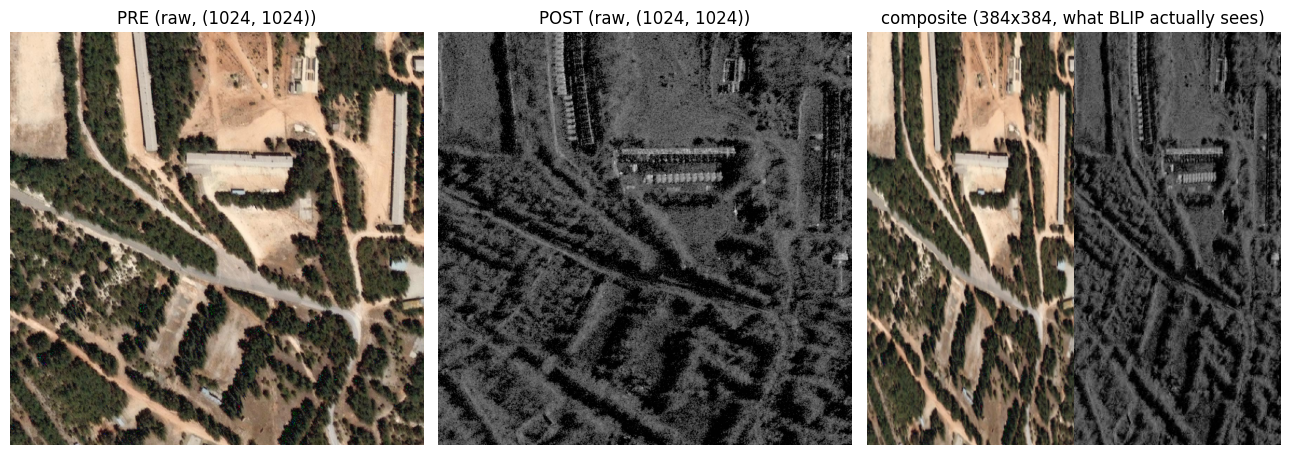


pixel_values tensor shape: (3, 384, 384)
pre half shape: (3, 384, 192), post half shape: (3, 384, 192)
halves genuinely differ, mean abs diff: 0.8591
negative control (same image twice), mean abs diff: 0.00e+00 (expect 0)


In [9]:
from scripts.dataset import ImageSpec, make_composite, load_image, composite_halves

spec = ImageSpec.from_processor(bundle.image_processor)
print("ImageSpec read from the checkpoint's own BlipImageProcessor:")
print(f"  size={spec.width}x{spec.height}  mean={spec.mean}  std={spec.std}  resample={spec.resample}")

example_rec = all_train_recs[7]
pre_img = load_image(example_rec["pre_image_path"])
post_img = load_image(example_rec["post_image_path"])
composite = make_composite(pre_img, post_img, spec)
pixel_values = spec.to_tensor(composite)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(pre_img); axes[0].set_title(f"PRE (raw, {pre_img.size})"); axes[0].axis("off")
axes[1].imshow(post_img); axes[1].set_title(f"POST (raw, {post_img.size})"); axes[1].axis("off")
axes[2].imshow(composite); axes[2].set_title(f"composite (384x384, what BLIP actually sees)"); axes[2].axis("off")
plt.tight_layout(); plt.show()

print(f"\npixel_values tensor shape: {tuple(pixel_values.shape)}")

pre_half, post_half = composite_halves(pixel_values)
print(f"pre half shape: {tuple(pre_half.shape)}, post half shape: {tuple(post_half.shape)}")
print(f"halves genuinely differ, mean abs diff: {(pre_half - post_half).abs().mean().item():.4f}")

# negative control: compositing the SAME image against itself must give MAD == 0
same_composite = make_composite(pre_img, pre_img, spec)
same_px = spec.to_tensor(same_composite)
same_pre, same_post = composite_halves(same_px)
print(f"negative control (same image twice), mean abs diff: {(same_pre - same_post).abs().mean().item():.2e} (expect 0)")

## 8. Real forward + backward pass on this composite, with the built model

Confirms the model, tokenizer, codec, and image pipeline are actually wired together correctly —
a real loss and real gradients on a real record, not a shape-only check.

In [10]:
bundle.model.train()
batch_recs = all_train_recs[7:9]
pixel_batch = torch.stack([
    spec.to_tensor(make_composite(load_image(r["pre_image_path"]), load_image(r["post_image_path"]), spec))
    for r in batch_recs
]).cuda()
enc = codec.encode_batch([r["ground_truth_id"] for r in batch_recs], device="cuda")

out = bundle.model(pixel_values=pixel_batch, input_ids=enc["input_ids"],
                    attention_mask=enc["attention_mask"], labels=enc["labels"])
print(f"logits shape: {tuple(out.logits.shape)}   loss: {out.loss.item():.4f}")

out.loss.backward()
emb = bundle.model.base_model.model.get_input_embeddings()
lora_grad_present = all(p.grad is not None and p.grad.abs().max().item() > 0
                        for n, p in bundle.model.named_parameters() if p.requires_grad and "lora_B" in n)
print(f"embedding grad present: {emb.weight.grad is not None}, mean|g|={emb.weight.grad.abs().mean().item():.2e}")
print(f"all lora_B modules have non-zero grad: {lora_grad_present}")
bundle.model.zero_grad(set_to_none=True)

logits shape: (2, 155, 31932)   loss: 13.1490
embedding grad present: True, mean|g|=4.56e-05
all lora_B modules have non-zero grad: True


## Summary

This notebook rebuilt the real Indonesian-adapted BLIP model end-to-end
(`build_model()`), verified the tokenizer's newline/section-header handling and round-trip
correctness on **all** real train records, inspected the real LoRA module placement and param
counts, rendered a real pre/post composite, and confirmed a real forward+backward pass produces a
finite loss with gradients flowing to both the embedding matrix and the LoRA adapters. See
`docs/design_decisions.md` (Fase 2 §0-§9 and Fase 3 §3.0-§3.9) for the full design rationale
behind every choice exercised here.